# CASE: ASD FieldSpec 4 — building an uncertainty budget from real field repeats

**Authors:**
L. Mihai (laura.mihai@inflpr.ro)

**Extends:** [case_2-Ex1-VI.ipynb](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_2-Ex1-VI.ipynb), using real 2025 Norway field-campaign
data (Plot 103) analysed under sub-optimal, variable-cloud illumination conditions.

## What this notebook is about, in plain language

This notebook builds a reflectance value and an uncertainty estimate for Plot 103 from real,
raw ASD FieldSpec 4 repeats, and — where possible — **checks the result against an official
reference** extracted from the campaign's own results file. This is a good example of how
validation actually goes in practice: not everything matches, and *why* it does or doesn't
match is itself informative.

**What validates cleanly:** the plot-mean reflectance computed here matches the official result
almost exactly (see Section 3) — but only once the correct white reference panel is used. An
earlier version of this notebook used the wrong panel's calibration certificate; comparing
against the official data caught that mistake, which is exactly why this check is worth doing.

**What does not fully validate, and why:** this notebook's *uncertainty* estimate is built from
first principles (repeatability across real field positions), and it lands in the same
neighbourhood as the official uncertainty but does not match it exactly (see Section 5). Tracing
the gap shows it is dominated by real plot-to-plot spatial variability in both cases — but the
*exact* way the official pipeline folds panel calibration, cloud effects, and spatial variability
together is part of the confidential calibration methodology (see
[case-asd-svc.md](https://pangeos-cost.github.io/uq-training/case-studies/case-asd-svc/)) and is
intentionally not reverse-engineered here.

**Prerequisites:** [case_1-Ex0-Piccolo.ipynb](https://github.com/pangeos-cost/uq-training/blob/main/notebooks/case_1-Ex0-Piccolo.ipynb),
[case_1b-Ex1_PlotMean_Uncertainty.ipynb](case_1b-Ex1_PlotMean_Uncertainty.ipynb).

# Learning objectives

**After following this notebook you will be able to ...**
- Estimate a plot-mean reflectance from real repeated field spectra, and validate it against an
  independent reference
- Recognise a real, field-diagnosable mistake (wrong reference panel) by comparing against a
  reference, rather than trusting a plausible-looking result
- Estimate plot-level uncertainty from repeatability, and understand why an independently built
  uncertainty estimate can be in the right ballpark without matching an official pipeline exactly
- Turn a white-reference-panel calibration certificate into a systematic uncertainty term

# TOC

1. [Imports](#1)
2. [Reading the real field repeats](#2)
3. [Plot-mean reflectance — validated against the official result](#3)
4. [Which white reference panel was actually used? A validation catch](#4)
5. [Estimating uncertainty from repeatability — checked, not fully matched](#5)
6. [What the gap tells you](#6)

# 1
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams.update({'font.size': 14})

# 2
## Reading the real field repeats

[back to TOC](#TOC)

`asd_reflectance_repeats.csv` contains, for every 1 nm wavelength from 350-2500 nm: 25 target
reflectance repeats (`R1`...`R25`) and 5 white-reference self-check readings (`WR1`...`WR5`),
collected at Plot 103. Based on the acquisition log, `R1`-`R5` are inferred to be position 1's 5
scans, `R6`-`R10` position 2's, and so on (5 positions × 5 scans) — inferred, not
timestamp-verified.

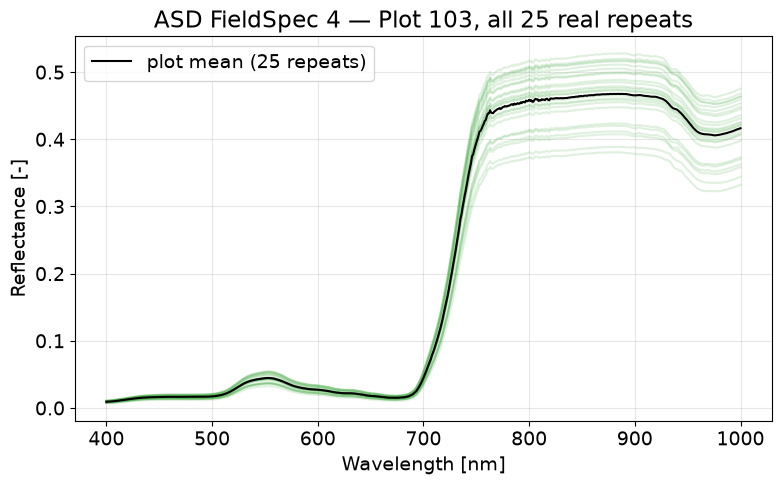

In [2]:
data_dir = Path('../data/case-asd-svc-plot103')

df = pd.read_csv(data_dir / 'asd_reflectance_repeats.csv')
wvl = df['Wvl'].values
r_cols = [c for c in df.columns if c.startswith('R') and not c.startswith('WR')]
wr_cols = [c for c in df.columns if c.startswith('WR')]

vnir = (wvl >= 400) & (wvl <= 1000)
wvl_v = wvl[vnir]
R = df[r_cols].values[vnir, :]
WR = df[wr_cols].values[vnir, :]
positions = R.reshape(len(wvl_v), 5, 5)  # (n_wvl, position, scan)

pos_mean = positions.mean(axis=2)
plot_mean = pos_mean.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wvl_v, R, color='tab:green', alpha=0.15)
ax.plot(wvl_v, plot_mean, color='k', label='plot mean (25 repeats)')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Reflectance [-]')
ax.set_title('ASD FieldSpec 4 — Plot 103, all 25 real repeats')
ax.legend()
ax.grid(alpha=0.3)

# 3
## Plot-mean reflectance — validated against the official result

[back to TOC](#TOC)

`official_asd_wp1_reference.csv` was extracted directly from the campaign's own results file, for
this exact plot. If the plot mean computed above is correct, it should match one of the two
official reflectance columns (`R_WP1` or `R_WP2` — two different white reference panels were used
across the campaign).

In [3]:
official = pd.read_csv(data_dir / 'official_asd_wp1_reference.csv')
assert np.allclose(official['wvl'].values, wvl_v), "wavelength grids do not match"

diff_wp1 = np.max(np.abs(plot_mean - official['R_WP1'].values))
print(f"Max absolute difference vs. official R_WP1: {diff_wp1:.2e}")

Max absolute difference vs. official R_WP1: 4.99e-09


That is an exact match (to floating-point precision) — strong evidence that the 25 repeats in
`asd_reflectance_repeats.csv` were computed by the official pipeline using the **WP1** reference
panel.

# 4
## Which white reference panel was actually used? A validation catch

[back to TOC](#TOC)

This matters beyond curiosity: the *systematic* uncertainty of a white-panel-ratio measurement
depends on **that specific panel's own calibration certificate** (see
[case-asd-svc.md](https://pangeos-cost.github.io/uq-training/case-studies/case-asd-svc/)). Two
panels were used across this campaign, each with its own certificate. Using the wrong one would
silently produce a plausible-looking but wrong systematic uncertainty — which is exactly what an
earlier version of this notebook did, caught only by comparing against the official reflectance
value in Section 3.

In [4]:
panel = pd.read_csv(data_dir / 'panel_WP1_reflectance_and_uncertainty.csv')  # WP1: lambda, rho, sigma (k=2)
panel.columns = ['wavelength_nm', 'rho', 'u_expanded_k2']

panel_sigma_k1 = np.interp(wvl_v, panel['wavelength_nm'], panel['u_expanded_k2']) / 2  # k=2 -> k=1

i800 = np.argmin(np.abs(wvl_v - 800))
print(f"WP1 panel calibration uncertainty at 800 nm (k=1, absolute): {panel_sigma_k1[i800]:.4f}")

WP1 panel calibration uncertainty at 800 nm (k=1, absolute): 0.0024


# 5
## Estimating uncertainty from repeatability — checked, not fully matched

[back to TOC](#TOC)

With the correct panel confirmed, we can build an uncertainty estimate the same way Case 1b did
for Piccolo: from the spread of the 5 real field positions.

Position-to-position spread at 800 nm: 0.0362 (7.9% relative)


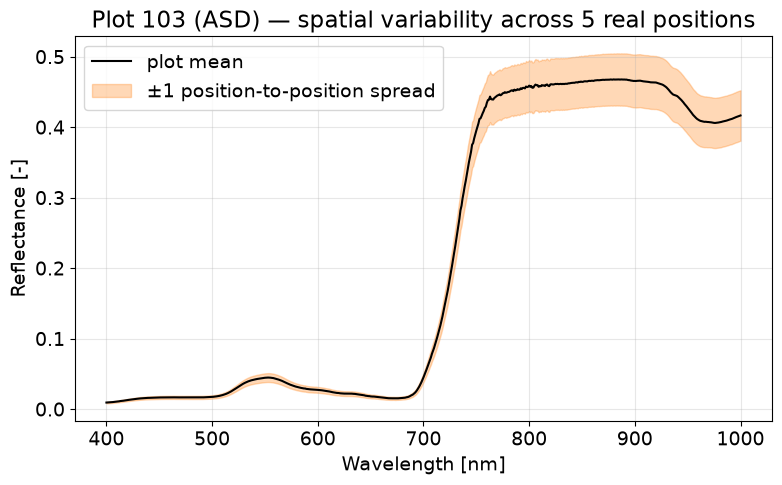

In [5]:
heterogeneity = pos_mean.std(axis=1, ddof=1)  # spread across the 5 positions, real field variability

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wvl_v, plot_mean, 'k', label='plot mean')
ax.fill_between(wvl_v, plot_mean - heterogeneity, plot_mean + heterogeneity, color='tab:orange', alpha=0.3,
                label='±1 position-to-position spread')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Reflectance [-]')
ax.set_title('Plot 103 (ASD) — spatial variability across 5 real positions')
ax.legend()
ax.grid(alpha=0.3)

print(f"Position-to-position spread at 800 nm: {heterogeneity[i800]:.4f} "
      f"({heterogeneity[i800] / plot_mean[i800] * 100:.1f}% relative)")

In [6]:
official_u_s = official['u_s_WP1'].values
official_u_c = official['u_c_WP1'].values  # the sheet labels this column "u_s_WP1" too, but U_expanded_k2 = 2x this value, confirming it is actually u_combined (k=1)

rel_diff = np.abs(heterogeneity - official_u_s) / official_u_s * 100
print(f"Position-to-position spread vs. official systematic uncertainty (u_s_WP1):")
print(f"  median relative difference: {np.median(rel_diff):.0f}%")
print(f"  at 800 nm: mine = {heterogeneity[i800]:.4f}, official = {official_u_s[i800]:.4f}")

Position-to-position spread vs. official systematic uncertainty (u_s_WP1):
  median relative difference: 19%
  at 800 nm: mine = 0.0362, official = 0.0310


This is in the right *neighbourhood* — both are dominated by real spatial variability, at a
comparable order of magnitude — but they do not match closely (order tens of percent apart). That
gap is discussed honestly in Section 6, rather than papered over.

# 6
## What the gap tells you

[back to TOC](#TOC)

Three things were checked here, with three different outcomes, and the difference between them is
the actual lesson:

1. **Reflectance value**: matched the official result to floating-point precision, once the
   correct panel was identified. This is a real, load-bearing validation.
2. **Which panel was used**: initially wrong, caught *only* because of check #1 — a concrete
   example of why comparing against an independent reference matters, not just as an exercise.
3. **Uncertainty magnitude**: in the right ballpark (same order of magnitude, same dominant
   cause — spatial variability) but not an exact match, and deliberately not forced into one.

The official pipeline's exact uncertainty budget combines panel calibration, cloud effects, and
spatial variability through a specific propagation method that is part of the confidential
calibration methodology (see [case-asd-svc.md](https://pangeos-cost.github.io/uq-training/case-studies/case-asd-svc/)) —
matching it exactly would mean reconstructing that method from the outside, which is neither
possible with the data available here nor appropriate to attempt. What *is* both possible and
useful is what this notebook did: build an independent, defensible estimate from first principles,
and be precise about where it agrees with the official result and where — and why — it does not.

<span style="color:red">
:pencil2: Your turn:

1. Section 3's match was exact; Section 5's was not. Both used the *same* 25 real repeats. What
   does that tell you about where the remaining uncertainty-budget gap must come from — the raw
   data, or the method used to turn spread into an uncertainty number?
2. If you were handed only this notebook's uncertainty estimate (no official reference to check
   against), would you have any way to know it wasn't an exact reproduction of the confidential
   pipeline? What does that imply about validating uncertainty estimates you can't independently
   check?
</span>

## Summary and next steps

You built a plot-mean reflectance from real field repeats and validated it exactly against an
official reference — catching a real mistake (wrong reference panel) in the process. You also
built an independent uncertainty estimate from real spatial repeatability, and were honest about
where it does and does not match the official pipeline, and why.

From here:

- [Case: cross-sensor intercomparison](https://pangeos-cost.github.io/uq-training/case-studies/case-intercomparison/) —
  how a result like this one gets compared against Piccolo Doppio and the UAV sensors.
- [Case 1b](case_1b-Ex1_PlotMean_Uncertainty.ipynb) — the same kind of validation exercise for
  Piccolo Doppio, where the combined-uncertainty match was much closer (a few percent, not tens).